# Анализ лояльности пользователей Яндекс Афиши

Автор: Егор Азовцев

Дата: 01.02.2026

### Цели и задачи проекта

Целью проекта является повышение доли клиентов, которые после одной покупки остаются на сервисе и совершают новые. Для этого нужно лучше понять поведение пользователей с помощью анализа данных. Анализ поможет сформировать рекомендации, которые позволят выявлять потенциальных постоянных клиентов и повысят общий уровень удержания.

### Содержимое проекта

- [**1. Загрузка данных и их предобработка.**](#section1)

[1.1. Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные.](#section1.1)  
[1.2. Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.](#section1.2)
    
    
- [**2. Предобработка данных.**](#section2)

[2.1. Приведите выручку к единой валюте — российскому рублю.](#section2.1)  
[2.2. Проверьте данные на пропущенные значения. Преобразуйте типы данных в некоторых столбцах, если это необходимо. Изучите значения в ключевых столбцах.](#section2.2)

- [**3. Создание профиля пользователя**](#section3)  

[3.1. Постройте профиль пользователя.](#section3.1)  
[3.2. Изучение репрезентативности выборки данных и определение статистических показателей.](#section3.2)  

- [**4. Исследовательский анализ данных.**](#section4)  

[4.1. Исследование признаков первого заказа и их связи с возвращением на платформу.](#section4.1)  
[4.1.1. Изучите распределение пользователей по признакам.](#section4.1.1)  
[4.1.2. Проанализируйте возвраты пользователей.](#section4.1.2)  
[4.1.3. Опираясь на выводы из задач выше, проверьте продуктовые гипотезы.](#section4.1.3)  
[4.2. Исследование поведения пользователей через показатели выручки и состава заказа.](#section4.2)  
[4.2.1. Проследите связь между средней выручкой сервиса с заказа и повторными заказами.](#section4.2.1)  
[4.2.2. Сравните распределение по средней выручке с заказа в двух группах пользователей.](#section4.2.2)  
[4.2.3. Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.](#section4.2.3)  
[4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки.](#section4.3)  
[4.3.1. Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.](#section4.3.1)  
[4.4. Корреляционный анализ количества покупок и признаков пользователя.](#section4.4)  
[4.4.1. Проведите корреляционный анализ.](#section4.4.1)  

- [**5. Общий вывод и рекомендации.**](#section5)

## Этапы выполнения проекта
<a id="section1"></a>
### 1. Загрузка данных и их предобработка

---
<a id="section1.1"></a>
**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Устанавливаем библиотеку SQLAlchemy
!pip install sqlalchemy

In [2]:
# Устанавливаем модуль psycopg2
!pip install psycopg2

In [3]:
# Импортируем нужные библиотеки и фунции
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import string
import phik

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Подключаемся к базе данных
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [5]:
# Формируем строку для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [6]:
# Создаём соединение
engine = create_engine(connection_string)

In [7]:
# Формируем SQL запрос для выгрузки данных
query = '''
SELECT
    user_id,
    device_type_canonical,
    order_id,
    created_dt_msk AS order_dt,
    created_ts_msk AS order_ts,
    currency_code,
    revenue,
    tickets_count, 
    created_dt_msk::date - LAG(created_dt_msk::date) 
        OVER(PARTITION BY user_id ORDER BY created_dt_msk)
        AS days_since_prev,
    event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    service_name,
    r.region_name,
    c.city_name   
FROM afisha.purchases
INNER JOIN afisha.events AS e USING (event_id)
INNER JOIN afisha.city AS c USING (city_id)
INNER JOIN afisha.regions AS r USING (region_id)
WHERE
    device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
ORDER BY user_id
'''

In [8]:
# Записываем в датафрейм 
df = pd.read_sql_query(query, con=engine)

In [9]:
#Выводим первые пять строк и информацию из датасета
display(df.head())
df.info()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---
<a id="section1.2"></a>
**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Полученная выгрузка данных содержит 290611 строк и 15 столбцов, в которых представлена информация о пользователях и сделанных ими заказах. После первичного анализа можно сделать следующие выводы:
1. Данные соответствуют описанию, типы данных соответствуют представленным данным.
2. Для столбца `tickets_count`можно сократить размерность.
3. Пропуски содержатся только в столбце с количеством дней от предыдущей покупки `days_since_prev`, что соответствует пользователям с одной покупкой.
4. В поле revenue встречаются отрицательные значения, нужно посмотреть, с чем это связано.

---
<a id="section2"></a>
###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---
<a id="section2.1"></a>
**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [10]:
# Выгружаем данные в переменные 
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [11]:
display(final_tickets_tenge_df.head())
final_tickets_tenge_df.info()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [12]:
# Приведём столбец data и order_dt к одному формату
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

In [13]:
# Объединим датафреймф по датам
df_merged = df.merge(final_tickets_tenge_df[['data', 'curs', 'nominal']], 
                     left_on='order_dt', right_on='data', how='left')

In [14]:
# Создаем новый столбец
df_merged['revenue_rub'] = df_merged.apply(
    lambda row: row['revenue'] if row['currency_code'] == 'rub' 
                else row['revenue'] * (row['curs'] / row['nominal']) if pd.notna(row['curs']) else np.nan, 
    axis=1
)

df_merged['revenue_rub'] = df_merged['revenue_rub'].round(2)

In [15]:
# Удаляем вспомогательные столбцы (data, curs, nominal) и обновляем df
df_merged = df_merged.drop(['data', 'curs', 'nominal'], axis=1, errors='ignore')
df = df_merged

In [16]:
# Проверяем
display(df[df['currency_code'] == 'kzt'].head())
df.info()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,98.50
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,65.73
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,61.15
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,4380.70
460,01370a0e9c1a7d5,mobile,2229811,2024-06-04,2024-06-04 13:19:47,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1478.30


<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

---
<a id="section2.2"></a>
**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Пропуски в данных встречаются только в столбце `days_since_prev`.

Проведём преобразование типов числовых данных, сократив размерность. 

In [17]:
#переведём столбец tickets_count в int8
df['tickets_count'] = df['tickets_count'].astype('int8')

Для поиска ошибок и дубликатов нормализуем столбцы `event_type_main`, `service_name`, `region_name` и `city_name` - приведём к нижнему регистру, удалим лишние пробелы и знаки перпинания.

In [18]:
#Переведём значения в столбцах к нижнему регистру
df['event_type_main'] = df['event_type_main'].str.lower()
df['service_name'] = df['service_name'].str.lower()
df['region_name'] = df['region_name'].str.lower()
df['city_name'] = df['city_name'].str.lower()

#Удалим знаки препинания и лишние пробелы
df['event_type_main'] = df['event_type_main'].str.translate(str.maketrans('', '', string.punctuation))
df['event_type_main'] = df['event_type_main'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['service_name'] = df['service_name'].str.translate(str.maketrans('', '', string.punctuation))
df['service_name'] = df['service_name'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['region_name'] = df['region_name'].str.translate(str.maketrans('', '', string.punctuation))
df['region_name'] = df['region_name'].str.strip().str.replace(r'\s+', ' ', regex=True)
df['city_name'] = df['city_name'].str.translate(str.maketrans('', '', string.punctuation))
df['city_name'] = df['city_name'].str.strip().str.replace(r'\s+', ' ', regex=True)

Проверьте столбцы с номинальными данными на наличие ошибок, дубликатов, а также есть ли среди них значения, которые обозначают пропуски в данных или отсутствие информации. Столбцы `device_type_canonical` и `currency_code` проверялись в прошлых уроках спринта с проектом.

In [19]:
# Выводим уникальные значения из столбца event_type_main
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

В данном столбце встречается категория `другое`. Вероятно, это категория обозначает мероприятия, которые не подходят ни под одну другую. Оценим долю таких записей. 

In [20]:
# Счиатем долю 
display((df['event_type_main'] == 'другое').mean() * 100)

22.66500579812877

Таких записей примерно 22,7%, это довольно существенный процент. Оставим эти записи. Далее проверим названия билетных операторов.

In [21]:
# Выводим уникальные значения из столбца service_name и отсортируем по алфавиту
sorted(df['service_name'].unique())

['crazy ticket',
 'showticket',
 'билет по телефону',
 'билеты без проблем',
 'билеты в интернете',
 'билеты в руки',
 'быстробилет',
 'быстрый кассир',
 'весь в билетах',
 'восьмёрка',
 'вперёд',
 'выступленияру',
 'городской дом культуры',
 'дом культуры',
 'дырокол',
 'за билетом',
 'зе бест',
 'карандашру',
 'кино билет',
 'край билетов',
 'лимоны',
 'лови билет',
 'лучшие билеты',
 'мир касс',
 'мой билет',
 'облачко',
 'прачечная',
 'радио ticket',
 'реестр',
 'росбилет',
 'тебе билет',
 'телебилет',
 'тех билет',
 'цвет и билет',
 'шоу начинается',
 'яблоко']

Явных и неявных дубликатов нет. Сравним количество уникальных билетных операторов в нашем датасете и исходном.

In [22]:
# Уникальное количество агентов из датасета
display(f"Уникальных билетных операторов в датасете: {df['service_name'].nunique()}")

# Уникальное количество агентов из исходной базы данных
query_unique_service = '''
select count(distinct service_name)
from afisha.purchases p;
'''
df_qus = pd.read_sql_query(query_unique_service, con=engine)
display(f"Уникальных билетных операторов в исходной базе: {df_qus.iloc[:, 0].iloc[0]}")

'Уникальных билетных операторов в датасете: 36'

'Уникальных билетных операторов в исходной базе: 36'

Количество одинаковое, значит при агрегации и нормализации мы не потеряли билетных агентов. Теперь исследуем регионы. Посчитаем количество регионов в датасете и исходной базе данных. 

In [23]:
# Уникальное количество регионов из датасета
display(f"Уникальных регионов в датасете: {df['region_name'].nunique()}")

# Уникальное количество регионов из исходной базы данных
query_unique_region = '''
select count(distinct region_name)
from afisha.regions p;
'''
df_qur = pd.read_sql_query(query_unique_region, con=engine)
display(f"Уникальных регионов в исходной базе: {df_qur.iloc[:, 0].iloc[0]}")

'Уникальных регионов в датасете: 81'

'Уникальных регионов в исходной базе: 81'

Количество совпадает. Посмотрим на города. В исходной базе данных было 353 уникальных города по столбцу `city_id` (мы выяснили это в одном из предыдущих уроков проекта модуля). Посмотрим, сколько уникальных значений в нашем датасете по столбцу `city_name`

In [24]:
display(f"Уникальных названий городов в датасете: {df['city_name'].nunique()}")

'Уникальных названий городов в датасете: 352'

Уникальных названий в полученном датасете меньше на один - 352. Первое, что приходит на ум - возможно в разных регионах есть города с одинаковым названием. Найдём это название и посмотрим в каких регионах находятся эти города.

In [25]:
# Считаем количество названий города, больше одного раза встречающегося в базе данных
query_cities = '''
select distinct city_name, count(city_name)
from afisha.city c 
group by city_name
having count(city_name) > 1
'''

display(pd.read_sql_query(query_cities, con=engine))

query_city_and_regions = '''
select c.city_name, r.region_name
from afisha.city c
inner join afisha.regions as r using (region_id)
where c.city_name = 'Глинополье'
'''

display(pd.read_sql_query(query_city_and_regions, con=engine))

,city_name,count
0,Глинополье,2


,city_name,region_name
0,Глинополье,Голубевский округ
1,Глинополье,Солнечноземская область


В базе данных и в нашем датасете два раза встречается город Глинополье - один из Голубевского округа, а один - из Солнечноземской области. Нужно будет иметь это ввиду при группировке и анализе.

Проверим столбцы с числовыми значиями - с выручкой с заказа (`revenue_rub`) и с количеством билетов в заказе (`tickets_count`).
Изучим статистические показатели столбца с выручкой.

In [26]:
# Изучаем статистические показатели столбца revenue_rub
print('Статистические показатели столбца revenue_rub:')
df['revenue_rub'].describe()

Статистические показатели столбца revenue_rub:


count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
25%         113.970000
50%         351.140000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

Во-первых, в датасете есть отрицательные значения.  
Во-вторых, распределение имеет явное правое ассимитричное распределение. Об этом говорит то, что среднее значение 625,58 больше медианного 356,01.

In [27]:
# Проверим количество отрицательных и нудевых значений в абсолютных и относительных числах
total = len(df)
neg = (df['revenue_rub'] < 0).sum()
pos = (df['revenue_rub'] > 0).sum()
zero = (df['revenue_rub'] == 0).sum()

print(f"Всего: {total}")
print(f"Отрицательных: {neg} ({neg/total*100:.1f}%)")
print(f"Положительных: {pos} ({pos/total*100:.1f}%)")
print(f"Нулей: {zero} ({zero/total*100:.1f}%)")

Всего: 290611
Отрицательных: 381 (0.1%)
Положительных: 284704 (98.0%)
Нулей: 5526 (1.9%)


С чем могут быть связаны отрицательные и нулевые значения? Отрицательные значения могут быть корректировками суммы заказа или кешбэками. Нулевые значения могу указывать на бесплатные мероприятия. Количество таких строк относительно невелико, 2% от общего числа, отфильтруем эти значения, так как они будут снижать среднюю выручку при анализе.  

In [28]:
# Оставим только положительные значения
df_filtered = df[df['revenue_rub'] > 0]

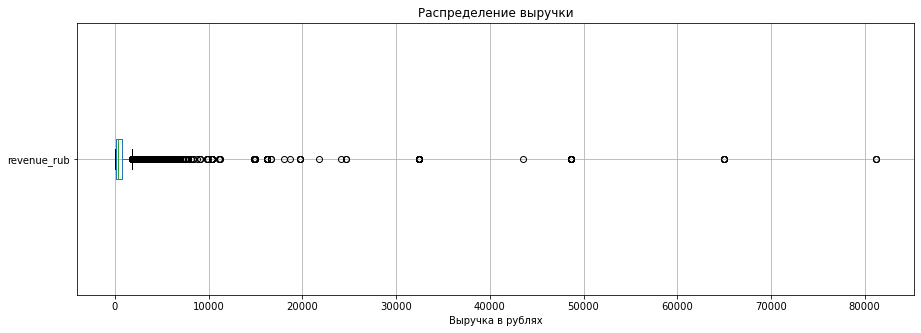

In [29]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
df_filtered.boxplot(column='revenue_rub', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение выручки')
plt.xlabel('Выручка в рублях')

# Выводим график
plt.show()

Явно присутсвуют выбросы. Отфильтруем значения по 99 перцентилю и построим новое распределение.

In [30]:
df_filtered = df_filtered[df_filtered['revenue_rub'] <= df_filtered['revenue_rub'].quantile(0.99)]

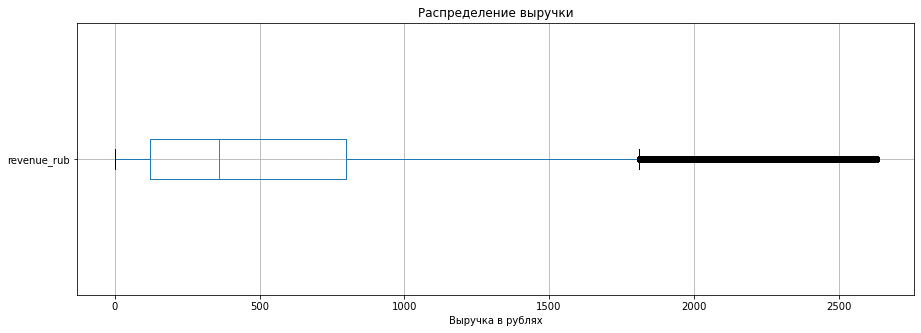

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
df_filtered.boxplot(column='revenue_rub', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение выручки')
plt.xlabel('Выручка в рублях')

# Выводим график
plt.show()

In [32]:
df_filtered.info()
# Изучаем статистические показатели столбца revenue_rub
print('Статистические показатели столбца revenue_rub:')
df_filtered['revenue_rub'].describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281879 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                281879 non-null  object        
 1   device_type_canonical  281879 non-null  object        
 2   order_id               281879 non-null  int64         
 3   order_dt               281879 non-null  datetime64[ns]
 4   order_ts               281879 non-null  datetime64[ns]
 5   currency_code          281879 non-null  object        
 6   revenue                281879 non-null  float64       
 7   tickets_count          281879 non-null  int8          
 8   days_since_prev        260491 non-null  float64       
 9   event_id               281879 non-null  int64         
 10  event_name             281879 non-null  object        
 11  event_type_main        281879 non-null  object        
 12  service_name           281879 non-null  obje

count    281879.000000
mean        528.888313
std         511.717247
min           0.020000
25%         122.690000
50%         358.290000
75%         798.070000
max        2628.420000
Name: revenue_rub, dtype: float64

Теперь посмотрим статичтические показатели столбца `tickets_count`.

In [33]:
# Изучаем статистические показатели столбца tickets_count
print('Статистические показатели столбца tickets_count:')
df_filtered['tickets_count'].describe()

Статистические показатели столбца tickets_count:


count    281879.000000
mean          2.744117
std           1.157190
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          47.000000
Name: tickets_count, dtype: float64

Посмотрим на распределение количества билетов. 

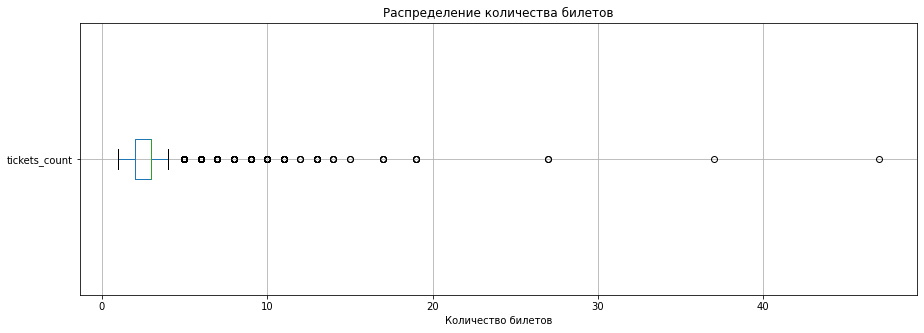

In [34]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
df_filtered.boxplot(column='tickets_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества билетов')
plt.xlabel('Количество билетов')

# Выводим график
plt.show()

Также видим выбросы справа, несколько заказов явно выбиваются из общего числа. Но так как мы убрали отрицательные и нулевые значения, потеря этих данных может повлиять на анализ, поэтому оставим как есть.

Оценим объём отфильтрованных данных.

In [35]:
size_df = len(df)
size_df_filtered = len(df_filtered)

# Относительная доля оставшихся данных
relative_diff = size_df_filtered / size_df * 100
print(f"Осталось {relative_diff:.1f}% от исходного датасета")
print(f"Потеряно {(100 - relative_diff):.1f}% данных")

Осталось 97.0% от исходного датасета
Потеряно 3.0% данных


После фильтрации мы потеряли 3% от общего числа, что является приемлемым значением.

Исходный датасет `df`, собранный по результатам выгрузки из базы данных содержал, 290611 строк и 15 столбцов с данными о заказах.  
1. Были переведены данные по выручке, приведённые в тенге, в рубли. Значения указаны в новом столбце `revenue_rub`. 
2. Сократил размерность для столбца `tickets_count`.
3. Нормализованы записи с названием типа мероприятия, регионов, городов и билетных операторов. Обнаружено, что в данных есть города с одинаковым названием, но из разных регионов. 
4. Из датасета были отфильтрованы отрицательные и нулевые значения выручки, а также выбросы в столбце `revenue_rub` по 99 процентилю. Всего было потеряно 3% данных от общего числа. Отфильтрованные датасет содержит 281879 строк и 16 столбцов.

---
<a id="section3"></a>
### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---
<a id="section3.1"></a>
**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [36]:
# Сначала отсортируем данные по пользователю и по времени совершения заказа
df_filtered = df_filtered.sort_values(['order_ts'])

In [37]:
# Формируем профиль пользователя
user_agg = (
    df_filtered.groupby('user_id')
      .agg(
          first_order_dt=('order_dt', 'min'),          # дата первого заказа
          last_order_dt=('order_dt', 'max'),           # дата последнего заказа
          orders_count=('order_id', 'nunique'),        # общее число заказов
          avg_revenue_rub=('revenue_rub', 'mean'),     # средняя выручка с заказа в рублях
          avg_tickets=('tickets_count', 'mean'),       # среднее количество билетов в заказе
          avg_days_between=('days_since_prev', 'mean') # среднее время между заказами
      )
).reset_index()

user_agg['avg_revenue_rub'] = user_agg['avg_revenue_rub'].round(2)
user_agg['avg_tickets'] = user_agg['avg_tickets'].round(2)

In [38]:
# Теперь агрегируем данные первого заказа
first_order_features = (
    df_filtered.groupby('user_id')
      .first()
      .reset_index()[[
          'user_id',
          'device_type_canonical',
          'region_name',
          'service_name',
          'event_type_main'
      ]]
      .rename(columns={
          'device_type_canonical': 'first_device_type',
          'region_name': 'first_region_name',
          'service_name': 'first_service_name',
          'event_type_main': 'first_event_type'
      })
)

In [39]:
# Собираем профиль вместе
user_profile = user_agg.merge(
    first_order_features,
    on='user_id',
    how='left'
)

In [40]:
# Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype('bool')
user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype('bool')

In [41]:
# Посмотрим результаты агрегации
display(user_profile.head())
user_profile.info()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,first_device_type,first_region_name,first_service_name,first_event_type,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.94,4.00,NaN,mobile,каменевский регион,край билетов,театр,False,False
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.01,3.00,75.0,mobile,каменевский регион,мой билет,выставки,True,False
2,000898990054619,2024-07-13,2024-10-23,3,767.21,2.67,51.0,mobile,североярская область,лови билет,другое,True,False
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.83,4.00,NaN,desktop,каменевский регион,край билетов,театр,False,False
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.31,1.50,16.0,mobile,поленовский край,лучшие билеты,театр,True,False


<class 'pandas.core.frame.DataFrame'>
Int64Index: 21700 entries, 0 to 21699
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             21700 non-null  object        
 1   first_order_dt      21700 non-null  datetime64[ns]
 2   last_order_dt       21700 non-null  datetime64[ns]
 3   orders_count        21700 non-null  int64         
 4   avg_revenue_rub     21700 non-null  float64       
 5   avg_tickets         21700 non-null  float64       
 6   avg_days_between    13450 non-null  float64       
 7   first_device_type   21700 non-null  object        
 8   first_region_name   21700 non-null  object        
 9   first_service_name  21700 non-null  object        
 10  first_event_type    21700 non-null  object        
 11  is_two              21700 non-null  bool          
 12  is_five             21700 non-null  bool          
dtypes: bool(2), datetime64[ns](2), float64(3), int

---
<a id="section3.2"></a>
**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [42]:
# Общее число пользователей в выборке
total_users = user_profile['user_id'].nunique()
print(f"Общее число пользователей в выборке: {total_users}")

Общее число пользователей в выборке: 21700


In [43]:
# Cредняя выручка с одного заказа
avg_revenue_per_order = round(
    user_profile['avg_revenue_rub']
    .mean(), 2
)

print(f"Общее средняя выручка с одного заказа составляет {avg_revenue_per_order} рублей")

Общее средняя выручка с одного заказа составляет 551.88 рублей


In [44]:
# Доля пользователей, совершивших 2 и более заказа
share_two_plus = round(user_profile['is_two'].mean(), 3)
print(f"Доля пользователей, совершивших 2 и более заказа составляет {share_two_plus*100}% от общего числа пользователей.")

Доля пользователей, совершивших 2 и более заказа составляет 61.7% от общего числа пользователей.


In [45]:
# Доля пользователей, совершивших 5 и более заказов
share_five_plus = round(user_profile['is_five'].mean(), 3)
print(f"Доля пользователей, совершивших 5 и более заказов составляет {share_five_plus*100}% от общего числа пользователей.")

Доля пользователей, совершивших 5 и более заказов составляет 28.9% от общего числа пользователей.


In [46]:
# Изучим статистические показатели по общему числу заказов
user_profile['orders_count'].describe()

count    21700.000000
mean        12.989816
std        119.766778
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9987.000000
Name: orders_count, dtype: float64

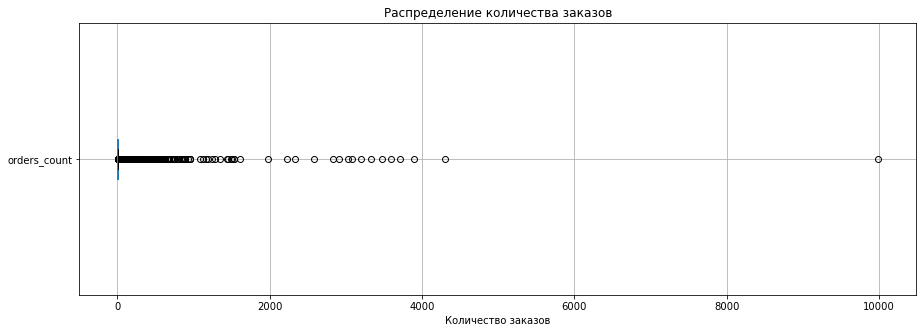

In [47]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
user_profile.boxplot(column='orders_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества заказов')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

Явно присутствуют выбросы. Целесообразно отфильтровать по 95-му перцентилю.

In [48]:
user_profile_filtered = user_profile[user_profile['orders_count'] <= user_profile['orders_count'].quantile(0.95)]

In [49]:
user_profile_filtered['orders_count'].describe()

count    20626.000000
mean         4.030738
std          5.079931
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: orders_count, dtype: float64

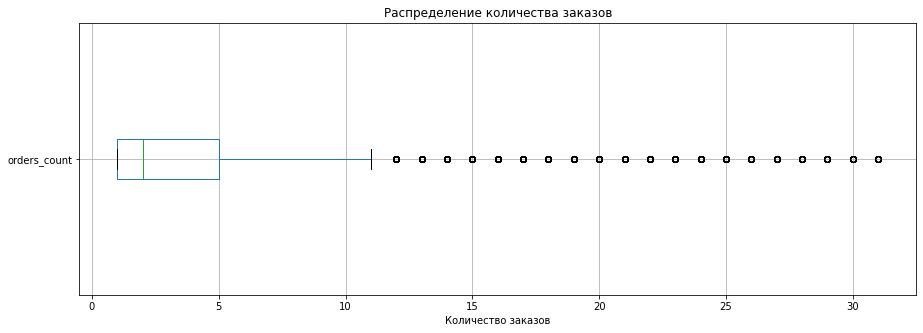

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
user_profile_filtered.boxplot(column='orders_count', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества заказов')
plt.xlabel('Количество заказов')

# Выводим график
plt.show()

In [51]:
# Изучим статистические показатели по среднему числу билетов в заказе
user_profile_filtered['avg_tickets'].describe()

count    20626.000000
mean         2.746406
std          0.935575
min          1.000000
25%          2.000000
50%          2.750000
75%          3.170000
max         11.000000
Name: avg_tickets, dtype: float64

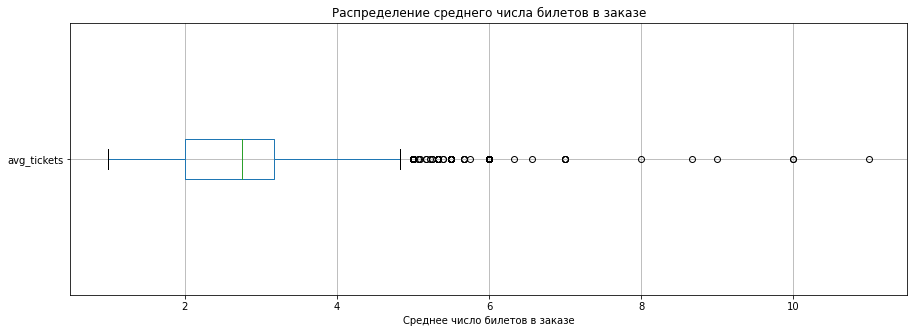

In [52]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
user_profile_filtered.boxplot(column='avg_tickets', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего числа билетов в заказе')
plt.xlabel('Среднее число билетов в заказе')

# Выводим график
plt.show()

Данные показатели вполне соотносятся с ожидаемыми, можно не проводить фильтрацию в данном случае.

In [53]:
# Изучим статистические показатели по среднему количеству дней между покупками
user_profile_filtered['avg_days_between'].describe()

count    12376.000000
mean        17.113863
std         22.928175
min          0.000000
25%          1.000000
50%          9.500000
75%         22.333333
max        148.000000
Name: avg_days_between, dtype: float64

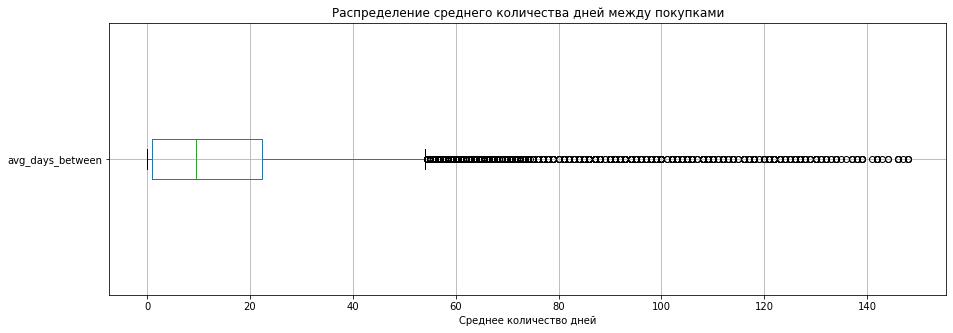

In [54]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 5))

# Строим диаграмму размаха значений
user_profile_filtered.boxplot(column='avg_days_between', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего количества дней между покупками')
plt.xlabel('Среднее количество дней')

# Выводим график
plt.show()

Распределение также имеет выбросы справа, но они вполне похожи на правду - разница между первой и последней покупкой может быть 148 дней.

После анализа репрезентативности выборки и анализа аномалий можно сделать следующие выводы:  
1. Объём данных в выборке достаточные для проведения анализа.  
2. Присутствуют аномальные значения в данных о количестве заказов. Принято решение отфильтровать их по 95-му перцентилю.  
3. В среднем количестве билетов также встречаются аномальные значения, но они, в целом, соответствуют действительности, такие значения могут встречаться.  

Оценим объём отфильтрованных данных.

In [55]:
size_user_profile = len(user_profile)
size_user_profile_filtered = len(user_profile_filtered)

# Относительная доля оставшихся данных
relative_diff_user = size_user_profile_filtered / size_user_profile * 100
print(f"Осталось {relative_diff_user:.1f}% от исходного датасета")
print(f"Потеряно {(100 - relative_diff_user):.1f}% данных")

Осталось 95.1% от исходного датасета
Потеряно 4.9% данных


Мы потеряли потреяли примерно 5% данных, отфильтровав по 95-му перцентилю выбросы в показателях с количеством заказов.

In [56]:
user_profile_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20626 entries, 0 to 21699
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             20626 non-null  object        
 1   first_order_dt      20626 non-null  datetime64[ns]
 2   last_order_dt       20626 non-null  datetime64[ns]
 3   orders_count        20626 non-null  int64         
 4   avg_revenue_rub     20626 non-null  float64       
 5   avg_tickets         20626 non-null  float64       
 6   avg_days_between    12376 non-null  float64       
 7   first_device_type   20626 non-null  object        
 8   first_region_name   20626 non-null  object        
 9   first_service_name  20626 non-null  object        
 10  first_event_type    20626 non-null  object        
 11  is_two              20626 non-null  bool          
 12  is_five             20626 non-null  bool          
dtypes: bool(2), datetime64[ns](2), float64(3), int

In [57]:
# Для всех числовых столбцов
user_profile_filtered.describe()

# Для конкретных столбцов с перцентилями
user_profile_filtered[['orders_count', 'avg_tickets', 'avg_revenue_rub']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)


,orders_count,avg_tickets,avg_revenue_rub
count,20626.000000,20626.000000,20626.000000
mean,4.030738,2.746406,553.804177
std,5.079931,0.935575,440.727859
min,1.000000,1.000000,0.070000
25%,1.000000,2.000000,210.087500
50%,2.000000,2.750000,467.340000
75%,5.000000,3.170000,787.030000
90%,10.000000,4.000000,1138.905000
95%,15.000000,4.000000,1397.045000
99%,26.000000,5.000000,1990.982500


---
<a id="section4"></a>
### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

<a id="section4.1"></a>

#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---
<a id="section4.1.1"></a>
**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [58]:
# Определим функцию для группировки 
def segment_distribution(df, col):
    res = (
        df.groupby(col)['user_id']
          .nunique()
          .reset_index(name='users_cnt')
    )
    res['users_share'] = res['users_cnt'] / res['users_cnt'].sum()
    return res.sort_values('users_cnt', ascending=False)

In [59]:
# Распределение пользователей по типу первого мероприятия
event_type_dist = segment_distribution(
    user_profile_filtered,
    'first_event_type'
)

event_type_dist

,first_event_type,users_cnt,users_share
2,концерты,9236,0.447784
1,другое,4994,0.242122
5,театр,4081,0.197857
4,стендап,1078,0.052264
3,спорт,740,0.035877
0,выставки,401,0.019441
6,ёлки,96,0.004654


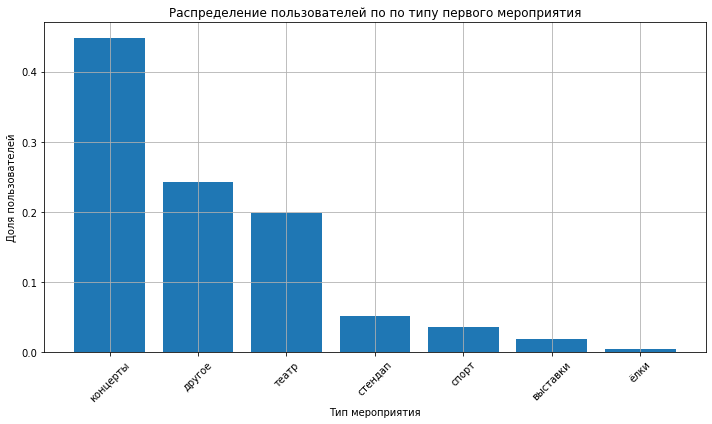

In [60]:
plt.figure(figsize=(10, 6))
plt.bar(event_type_dist['first_event_type'], event_type_dist['users_share'])
plt.title('Распределение пользователей по по типу первого мероприятия')
plt.ylabel('Доля пользователей')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [61]:
# Распределение по типу устройства, с которого была совершена первая покупка
device_dist = segment_distribution(
    user_profile_filtered,
    'first_device_type'
)

device_dist

,first_device_type,users_cnt,users_share
1,mobile,17115,0.829778
0,desktop,3511,0.170222


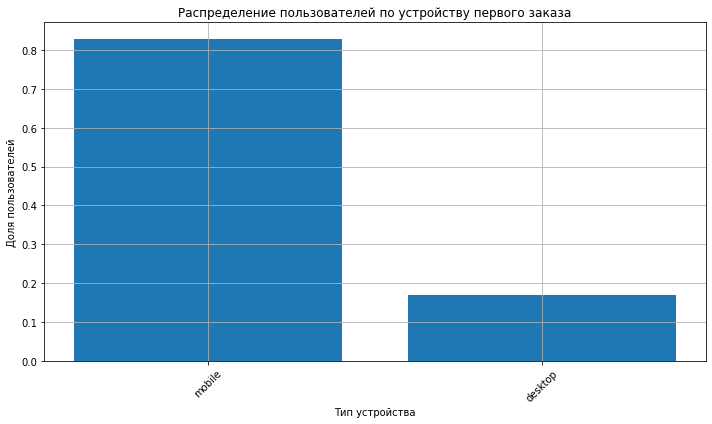

In [62]:
plt.figure(figsize=(10, 6))
plt.bar(device_dist['first_device_type'], device_dist['users_share'])
plt.title('Распределение пользователей по устройству первого заказа')
plt.ylabel('Доля пользователей')
plt.xlabel('Тип устройства')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [63]:
# Распределение по региону первого заказа
region_dist = segment_distribution(
    user_profile_filtered,
    'first_region_name'
)

# Покажем топ 10 регионов
region_dist.head(10)

,first_region_name,users_cnt,users_share
23,каменевский регион,6687,0.324202
60,североярская область,3616,0.175313
77,широковская область,1194,0.057888
45,озернинский край,662,0.032095
41,малиновоярский округ,517,0.025065
74,травяная область,441,0.021381
57,светополянский округ,440,0.021332
76,шанырский регион,426,0.020654
52,речиновская область,425,0.020605
78,яблоневская область,399,0.019345


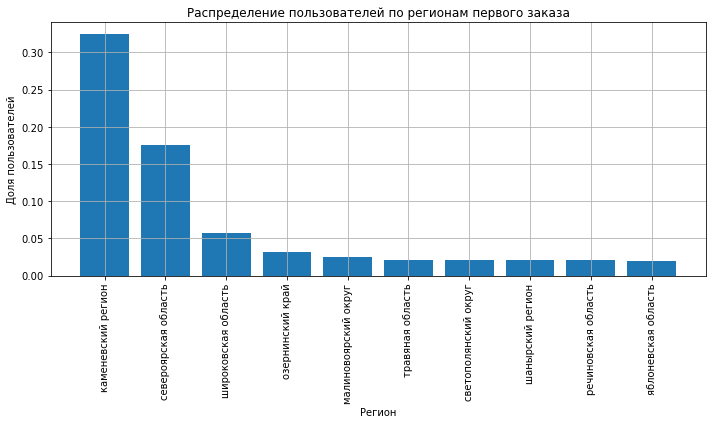

In [64]:
top_regions = region_dist.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_regions['first_region_name'], top_regions['users_share'])
plt.title('Распределение пользователей по регионам первого заказа')
plt.ylabel('Доля пользователей')
plt.xlabel('Регион')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid()
plt.show()

In [65]:
# Распределение по первому билетному оператору
service_dist = segment_distribution(
    user_profile_filtered,
    'first_service_name'
)

service_dist.head(10)

,first_service_name,users_cnt,users_share
3,билеты без проблем,4779,0.231698
22,мой билет,2878,0.139533
19,лови билет,2697,0.130757
4,билеты в руки,2414,0.117037
23,облачко,2128,0.103171
7,весь в билетах,1238,0.060021
20,лучшие билеты,1132,0.054882
24,прачечная,552,0.026762
17,край билетов,443,0.021478
12,дом культуры,342,0.016581


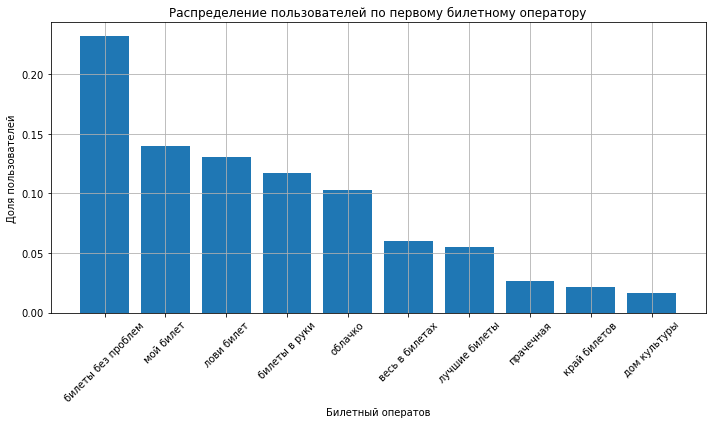

In [66]:
top_service = service_dist.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_service['first_service_name'], top_service['users_share'])
plt.title('Распределение пользователей по первому билетному оператору')
plt.ylabel('Доля пользователей')
plt.xlabel('Билетный оператов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

В каждом из распределений присутствуют явные точки входа:  
- по типу мероприятия - 44% пользователей первый билет покупают на концерт,
- по устройству - подавляющее большинство первый заказов сделаны с мобильных устройств,
- по региону - примерно треть первых заказов была сделана из Каменевского региона,
- по билетному оператору - самым популярным оператором для первого заказа является сервис "Билеты без проблем".

---
<a id="section4.1.2"></a>
**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Для начала вычислим долю пользователей, сделавших 2 и более заказа по всей выборке. С этим значением

In [67]:
overall_return_rate = user_profile_filtered['is_two'].mean()
print(f"Доля пользователей, совершивших 2 и более заказа составляет {round(overall_return_rate*100, 1)}% от общего числа пользователей.")

Доля пользователей, совершивших 2 и более заказа составляет 59.7% от общего числа пользователей.


In [68]:
# Определим функцию, по аналогии с предыдущей задачей, для анализа возвратов
def segment_return_rate(df, segment_col, top_n=None):
    res = (
        df.groupby(segment_col)
          .agg(
              users_cnt=('user_id', 'nunique'),
              return_rate=('is_two', 'mean')
          )
          .reset_index()
          .sort_values('users_cnt', ascending=False)
    )
    
    if top_n is not None:
        res = res.head(top_n)
        
    return res

In [69]:
# Доля возвратов по сегментам типа мероприятия
event_type_return = segment_return_rate(
    user_profile_filtered,
    'first_event_type'
)

event_type_return

,first_event_type,users_cnt,return_rate
2,концерты,9236,0.602425
1,другое,4994,0.575691
5,театр,4081,0.618966
4,стендап,1078,0.594620
3,спорт,740,0.533784
0,выставки,401,0.630923
6,ёлки,96,0.562500


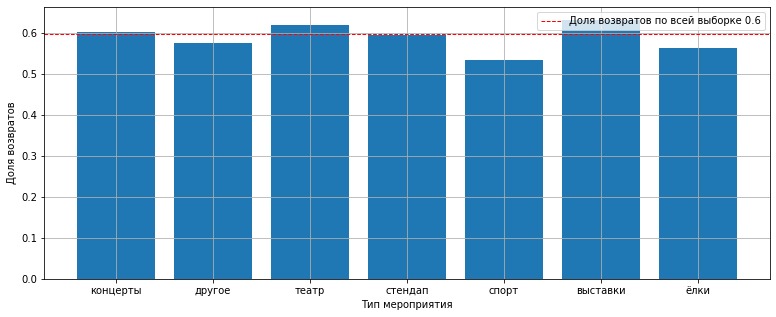

In [70]:
# Строим столбчатую диаграмму
plt.figure(figsize=(13, 5))
plt.bar(
    event_type_return['first_event_type'],
    event_type_return['return_rate']
)

# Построим линию, которая показывает долю сетевых заведений во всём датасете

plt.axhline(overall_return_rate, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля возвратов по всей выборке {round(overall_return_rate,2)}')

# Настраиваем оформление графика
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля возвратов')
plt.legend()
plt.grid()
# Выводим график
plt.show()

In [71]:
# Доля возвратов по сегментам устройства первого заказа
device_return = segment_return_rate(
    user_profile_filtered,
    'first_device_type'
)

device_return

,first_device_type,users_cnt,return_rate
1,mobile,17115,0.592346
0,desktop,3511,0.618058


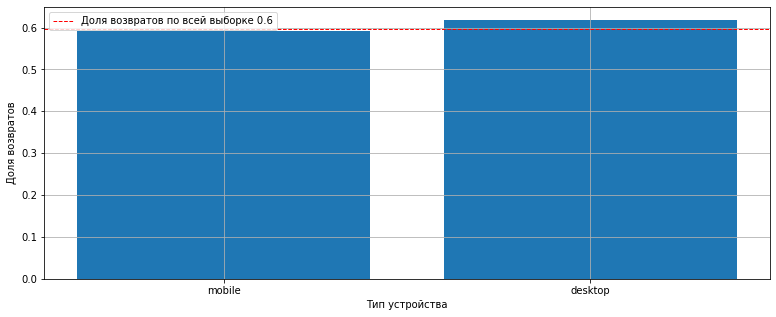

In [72]:
# Строим столбчатую диаграмму
plt.figure(figsize=(13, 5))
plt.bar(
    device_return['first_device_type'],
    device_return['return_rate']
)

# Построим линию, которая показывает долю сетевых заведений во всём датасете

plt.axhline(overall_return_rate, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля возвратов по всей выборке {round(overall_return_rate,2)}')

# Настраиваем оформление графика
plt.xlabel('Тип устройства')
plt.ylabel('Доля возвратов')
plt.legend()
plt.grid()
# Выводим график
plt.show()

In [73]:
# Доля возвратов по региону первого заказа
region_return = segment_return_rate(
    user_profile_filtered,
    'first_region_name',
    top_n=10
)

region_return

,first_region_name,users_cnt,return_rate
23,каменевский регион,6687,0.602811
60,североярская область,3616,0.623894
77,широковская область,1194,0.633166
45,озернинский край,662,0.540785
41,малиновоярский округ,517,0.549323
74,травяная область,441,0.598639
57,светополянский округ,440,0.640909
76,шанырский регион,426,0.666667
52,речиновская область,425,0.621176
78,яблоневская область,399,0.581454


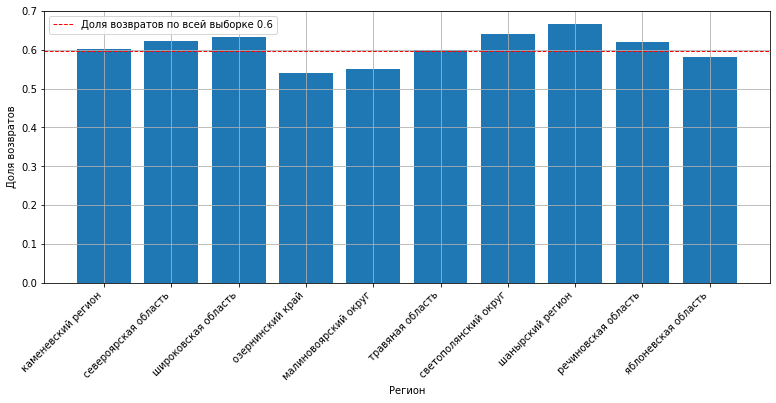

In [74]:
# Строим столбчатую диаграмму
plt.figure(figsize=(13, 5))
plt.bar(
    region_return['first_region_name'],
    region_return['return_rate']
)

# Построим линию, которая показывает долю сетевых заведений во всём датасете

plt.axhline(overall_return_rate, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля возвратов по всей выборке {round(overall_return_rate,2)}')

# Настраиваем оформление графика
plt.xlabel('Регион')
plt.ylabel('Доля возвратов')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid()
# Выводим график
plt.show()

In [75]:
# Доля возвратов по билетному оператору
service_return = segment_return_rate(
    user_profile_filtered,
    'first_service_name',
    top_n=10
)

service_return

,first_service_name,users_cnt,return_rate
3,билеты без проблем,4779,0.581712
22,мой билет,2878,0.591730
19,лови билет,2697,0.596218
4,билеты в руки,2414,0.608948
23,облачко,2128,0.601034
7,весь в билетах,1238,0.613086
20,лучшие билеты,1132,0.597173
24,прачечная,552,0.603261
17,край билетов,443,0.641084
12,дом культуры,342,0.631579


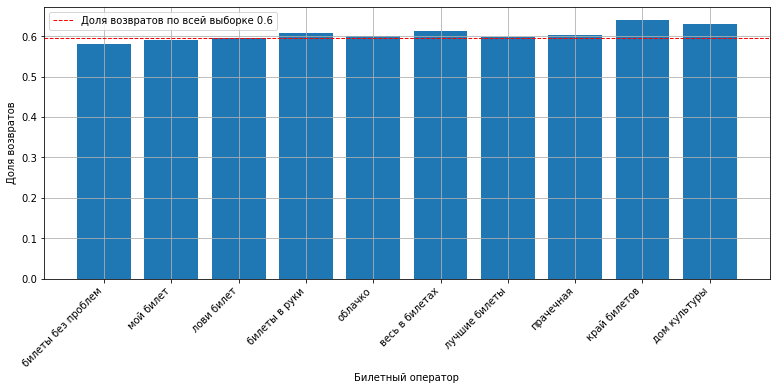

In [76]:
# Строим столбчатую диаграмму
plt.figure(figsize=(13, 5))
plt.bar(
    service_return['first_service_name'],
    service_return['return_rate']
)

# Построим линию, которая показывает долю сетевых заведений во всём датасете

plt.axhline(overall_return_rate, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля возвратов по всей выборке {round(overall_return_rate,2)}')

# Настраиваем оформление графика
plt.xlabel('Билетный оператор')
plt.ylabel('Доля возвратов')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid()
# Выводим график
plt.show()

В целом, доля возвратов в сегментах каждой группы колеблется относительно среднего значения по всей выборки, но можно отметить следующее:  
- по типу мероприятия - чаще всего возвращаются пользователи, которые первым мероприятием посетили выставку,
- по устройству - не намного, но чаще возвращаются пользователи, сделавшие первый заказ с стационарного устройства,
- по региону - самая большая доля возвратов в Шанырском регионе,
- по билетному оператору - на сервис "Край билетов" возвращались чаще.

---
<a id="section4.1.3"></a>
**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1 неверна: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ реже, чем пользователи, оформившие свой первый заказ на концерты - 53% и 60% соответственно.

Гипотеза 2 отчасти верна: в топ-3 регионах с наибольшим числом пользователей с первым заказом доля повторных заказов выше, чем в ряде регионов, с количетсвом пользователей меньше 1000. Однако самая большая доля возвратов в Шанырском районе - не самом активном регионе. 

---
<a id="section4.2"></a>
#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---
<a id="section4.2.1"></a>
**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [77]:
# Выделим группы пользователей
one_order_users = user_profile_filtered[user_profile_filtered['orders_count'] == 1]
returned_users = user_profile_filtered[user_profile_filtered['orders_count'] >= 2]

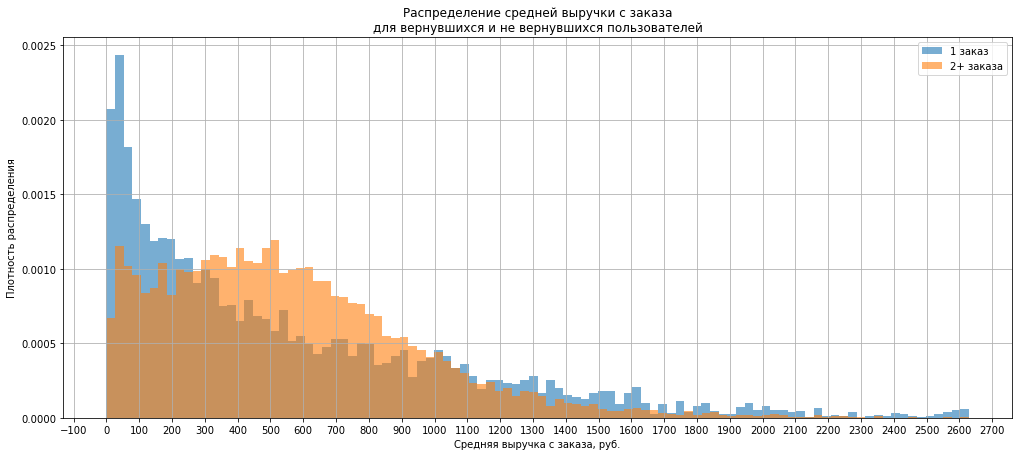

In [78]:
# Построим гистограмму
plt.figure(figsize=(17, 7))

plt.hist(
    one_order_users['avg_revenue_rub'],
    bins=100,
    alpha=0.6,
    density=True,
    label='1 заказ'
)

plt.hist(
    returned_users['avg_revenue_rub'],
    bins=100,
    alpha=0.6,
    density=True,
    label='2+ заказа'
)

plt.title('Распределение средней выручки с заказа\nдля вернувшихся и не вернувшихся пользователей')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.legend()
plt.locator_params(axis='x', nbins=40)
plt.grid()
plt.show()

Между группами есть различия явные различия: у вернувшихся пользователей пик средней выручки с заказа смещен вправо, пользователи концентрируются около значения в 500 рублей, однако есть локальный пик на уровне 50 рублей. У пользователей, сделавших один заказ средняя выручка имеет явный пик средней выручки около значения 40-50 рублей. 

---
<a id="section4.2.2"></a>
**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [79]:
# Выделим группы
users_2_4 = user_profile_filtered[(user_profile_filtered['orders_count'] >= 2) & (user_profile_filtered['orders_count'] <= 4)]
users_5_plus = user_profile_filtered[user_profile_filtered['orders_count'] >= 5]


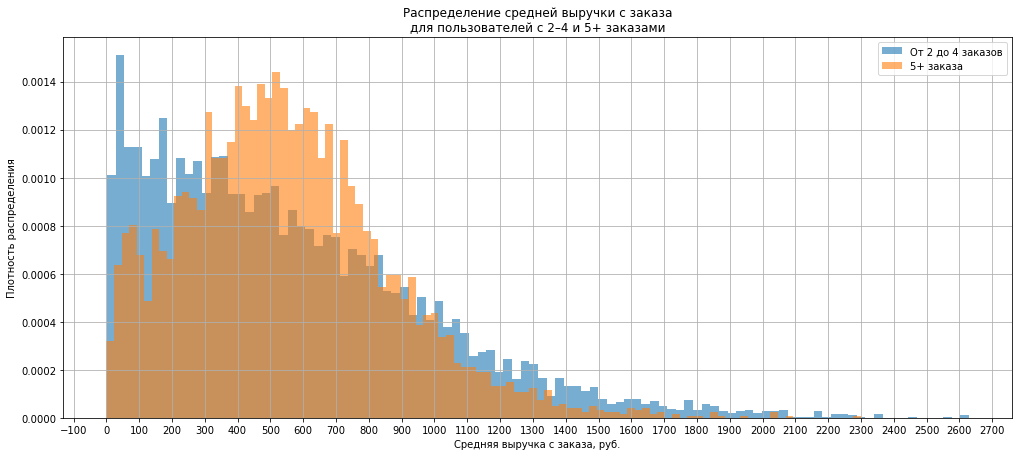

In [80]:
# Построим гистограмму
plt.figure(figsize=(17, 7))

plt.hist(
    users_2_4['avg_revenue_rub'],
    bins=100,
    alpha=0.6,
    density=True,
    label='От 2 до 4 заказов'
)

plt.hist(
    users_5_plus['avg_revenue_rub'],
    bins=100,
    alpha=0.6,
    density=True,
    label='5+ заказа'
)

plt.title('Распределение средней выручки с заказа\nдля пользователей с 2–4 и 5+ заказами')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.legend()
plt.locator_params(axis='x', nbins=40)
plt.grid()
plt.show()

In [81]:
users_2_4['avg_revenue_rub'].describe(), users_5_plus['avg_revenue_rub'].describe()

(count    7118.000000
 mean      557.673759
 std       420.043205
 min         2.420000
 25%       224.185000
 50%       477.645000
 75%       806.270000
 max      2628.420000
 Name: avg_revenue_rub, dtype: float64,
 count    5190.000000
 mean      550.301064
 std       313.406106
 min         0.350000
 25%       325.097500
 50%       522.760000
 75%       734.065000
 max      2299.870000
 Name: avg_revenue_rub, dtype: float64)

Средняя выручка с заказа практически не отличается.

---
<a id="section4.2.3"></a>
**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

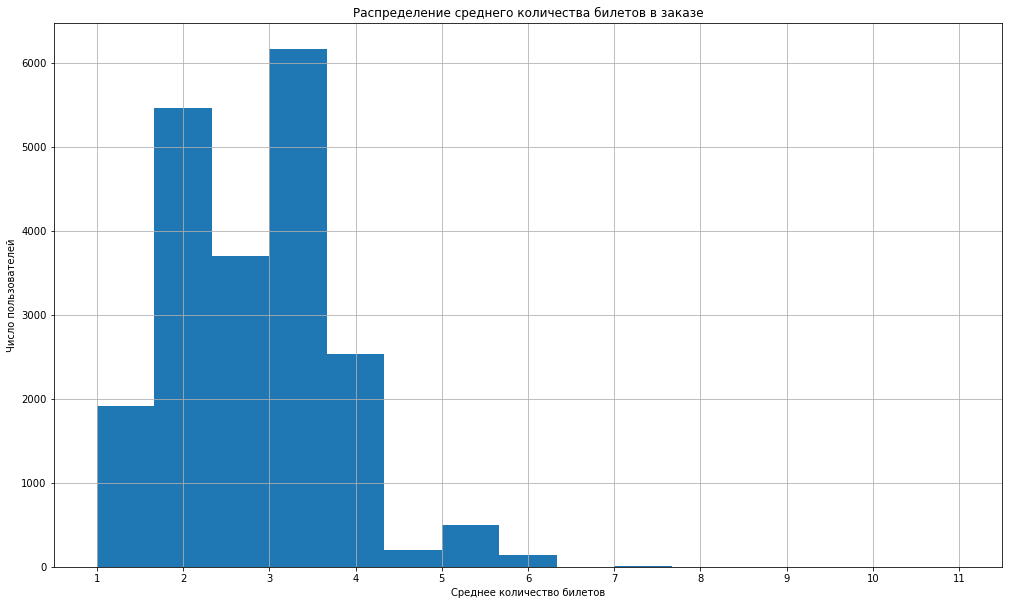

In [82]:
plt.figure(figsize=(17, 10))
user_profile_filtered['avg_tickets'].hist(bins=15)
plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Число пользователей')
plt.locator_params(axis='x', nbins=20)
plt.show()

Основная масса пользователей сосредоточена в диапазоне от 1 до 3-х билетов.

In [83]:
# Разделим пользователей на сегменты по среднему количеству билетов в заказе
user_profile_filtered = user_profile_filtered.copy()

bins = [0, 2, 3, 5, float('inf')]
labels = ['1–2 билета', '2–3 билета', '3–5 билетов', '5+ билетов']

user_profile_filtered['tickets_segment'] = pd.cut(
    user_profile_filtered['avg_tickets'],
    bins=bins,
    labels=labels,
    right=False
)

In [84]:
# Считаем общее число и долю пользователей
tickets_retention = (
    user_profile_filtered
    .groupby('tickets_segment')
    .agg(
        users_cnt=('user_id', 'nunique'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_retention

,tickets_segment,users_cnt,return_rate
0,1–2 билета,2387,0.511102
1,2–3 билета,8688,0.712592
2,3–5 билетов,8894,0.536654
3,5+ билетов,657,0.188737


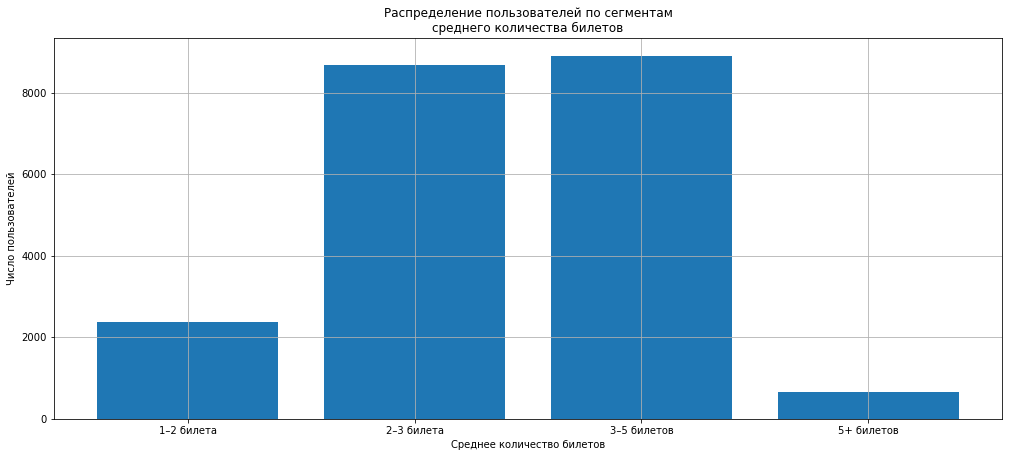

In [85]:
plt.figure(figsize=(17, 7))
plt.bar(
    tickets_retention['tickets_segment'],
    tickets_retention['users_cnt']
)

plt.title('Распределение пользователей по сегментам\nсреднего количества билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Число пользователей')
plt.grid()
plt.show()

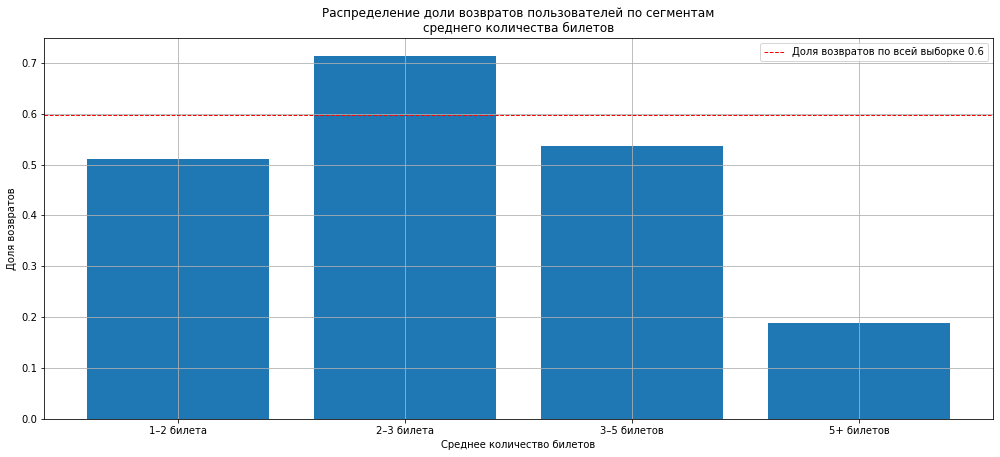

In [86]:
plt.figure(figsize=(17, 7))
plt.bar(
    tickets_retention['tickets_segment'],
    tickets_retention['return_rate']
)

plt.axhline(overall_return_rate, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля возвратов по всей выборке {round(overall_return_rate,2)}')

plt.title('Распределение доли возвратов пользователей по сегментам\nсреднего количества билетов')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Доля возвратов')
plt.grid()
plt.legend()
plt.show()

Пользователи распределены сконцентрированно - и доля, и количество возвратов больше в сегментах 2-3 билета и 3-5 билетов. Меньше всего возвратов пользователей в сегменте 5+.

---
<a id="section4.3"></a>
#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.



In [87]:
# Добавляем день недели первой покупки
user_profile_filtered['first_order_weekday'] = (
    user_profile_filtered['first_order_dt']
    .dt.day_name()
)

In [88]:
# Выведем статистику 
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekday_stats = (
    user_profile_filtered
    .groupby('first_order_weekday')
    .agg(users_cnt=('user_id', 'nunique'))
    .reindex(weekday_order)
    .reset_index()
)

weekday_stats['share'] = (
    weekday_stats['users_cnt'] / weekday_stats['users_cnt'].sum()
)

weekday_stats

,first_order_weekday,users_cnt,share
0,Monday,2797,0.135606
1,Tuesday,3011,0.145981
2,Wednesday,2952,0.143120
3,Thursday,3012,0.146029
4,Friday,3138,0.152138
5,Saturday,3095,0.150053
6,Sunday,2621,0.127073


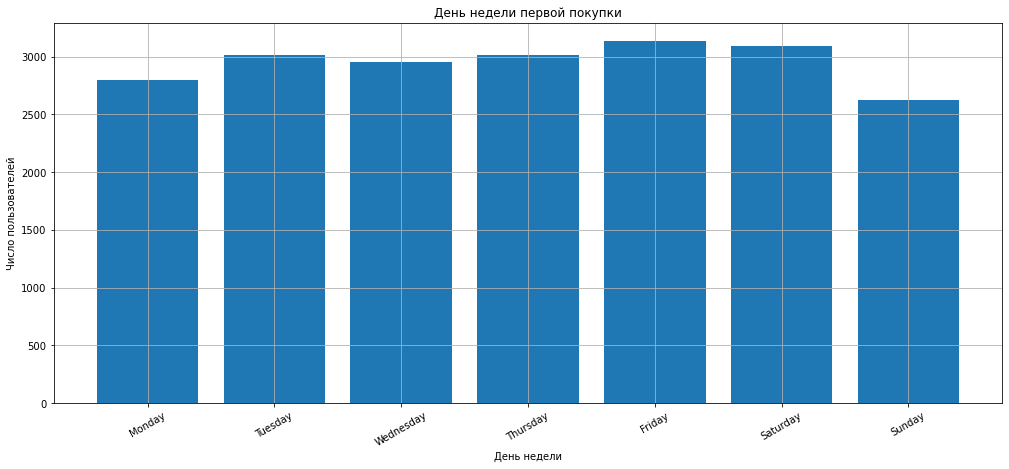

In [89]:
plt.figure(figsize=(17, 7))
plt.bar(
    weekday_stats['first_order_weekday'],
    weekday_stats['users_cnt']
)
plt.title('День недели первой покупки')
plt.xlabel('День недели')
plt.ylabel('Число пользователей')
plt.xticks(rotation=30)
plt.grid()
plt.show()


Пользователи неравномерно совершают покупки по дням недели, рост активности наблюдается в пятницу и субботу. 

In [90]:
# Рассчитаем лайфтайм в днях
user_profile_filtered['lifetime_days'] = (
    user_profile_filtered['last_order_dt']
    - user_profile_filtered['first_order_dt']
).dt.days

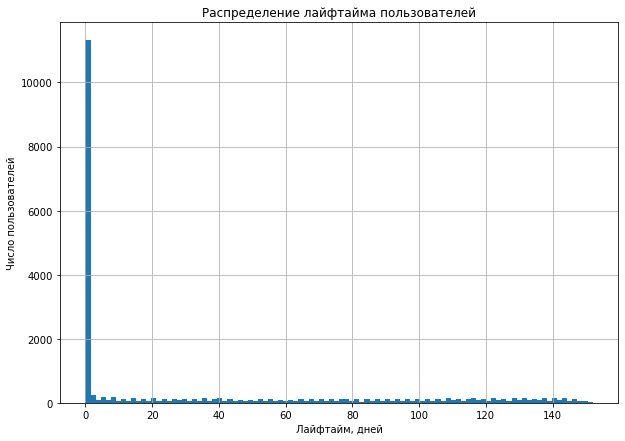

In [91]:
plt.figure(figsize=(10, 7))
plt.hist(
    user_profile_filtered['lifetime_days'],
    bins=100
)
plt.title('Распределение лайфтайма пользователей')
plt.xlabel('Лайфтайм, дней')
plt.ylabel('Число пользователей')
plt.grid()
plt.show()

Распределение лайфтайма пользователей имеет выраженную асимметрию: большинство пользователей совершают только несколько заказов, в то время как небольшая доля пользователей остаётся активной на протяжении длительного времени.

In [92]:
# Отбираем только вернувшихся пользователей
returned_users = user_profile_filtered.query('is_two')

In [93]:
returned_users['avg_days_between'].describe()

count    12308.000000
mean        16.962315
std         22.713252
min          0.000000
25%          1.000000
50%          9.436508
75%         22.000000
max        148.000000
Name: avg_days_between, dtype: float64

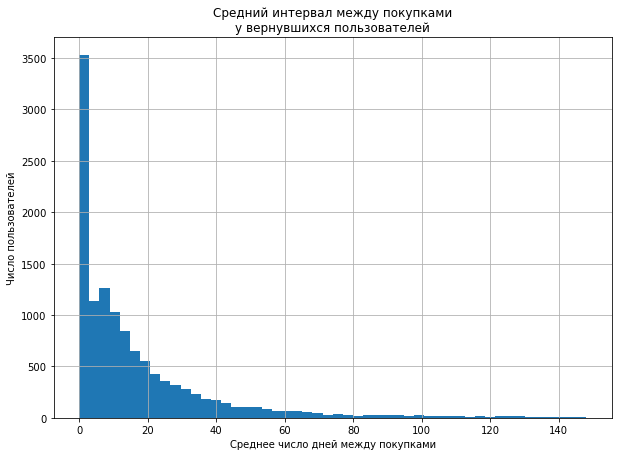

In [94]:
plt.figure(figsize=(10, 7))
plt.hist(
    returned_users['avg_days_between'],
    bins=50
)
plt.title('Средний интервал между покупками\nу вернувшихся пользователей')
plt.xlabel('Среднее число дней между покупками')
plt.ylabel('Число пользователей')
plt.grid()
plt.show()


Средний интервал между покупками у вернувшихся пользователей варьируется в широком диапазоне и имеет длинный правый хвост. Это указывает на неоднородность поведения пользователей: часть аудитории возвращается достаточно быстро, тогда как другие пользователи совершают повторные покупки спустя длительное время.


<a id="section4.3.1"></a>
**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?


In [95]:
weekday_retention = (
    user_profile_filtered
    .groupby('first_order_weekday')
    .agg(
        users_cnt=('user_id', 'nunique'),
        return_rate=('is_two', 'mean')
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_retention

,first_order_weekday,users_cnt,return_rate
0,Monday,2797,0.612442
1,Tuesday,3011,0.598804
2,Wednesday,2952,0.609417
3,Thursday,3012,0.583333
4,Friday,3138,0.587317
5,Saturday,3095,0.604200
6,Sunday,2621,0.581076


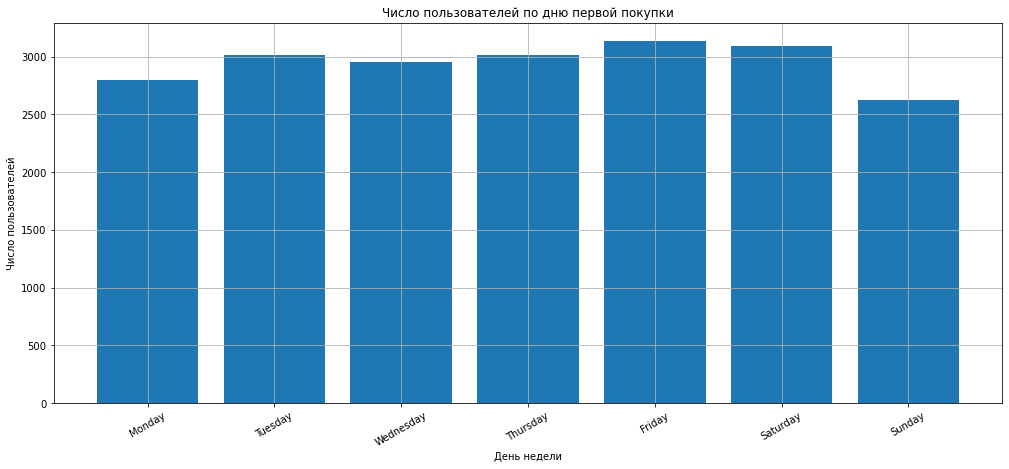

In [96]:
plt.figure(figsize=(17, 7))
plt.bar(
    weekday_retention['first_order_weekday'],
    weekday_retention['users_cnt']
)
plt.title('Число пользователей по дню первой покупки')
plt.xlabel('День недели')
plt.ylabel('Число пользователей')
plt.xticks(rotation=30)
plt.grid()
plt.show()

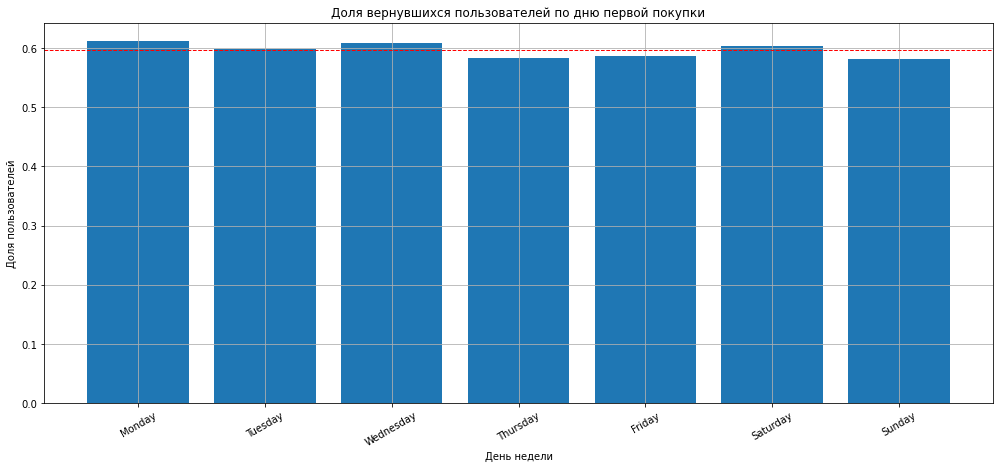

In [97]:
plt.figure(figsize=(17, 7))
plt.bar(
    weekday_retention['first_order_weekday'],
    weekday_retention['return_rate']
)

plt.axhline(overall_return_rate, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля возвратов по всей выборке {round(overall_return_rate,2)}')

plt.title('Доля вернувшихся пользователей по дню первой покупки')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей')
plt.xticks(rotation=30)
plt.grid()
plt.show()

Вероятность повторной покупки в целом слабо зависит от дня недели первой покупки. Для понедельника, среды и субботы доля пользователей, совершивших повторный заказ, превышает среднее значение по выборке, что может указывать на потенциальные точки входа. При этом различия между днями не носят резкого характера.

---
<a id="section4.3.2"></a>
**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [98]:
# Выделим вернувшихся пользователей
returned_users = user_profile_filtered.query('orders_count >= 2').copy()

In [99]:
# Создадим признаки группы
returned_users['orders_group'] = returned_users['orders_count'].apply(
    lambda x: '2–4 заказа' if x < 5 else '5+ заказов'
)

In [100]:
# Посмотрим описательную статистику
interval_stats = (
    returned_users
    .groupby('orders_group')['avg_days_between']
    .mean()
)

interval_stats

orders_group
2–4 заказа    21.238866
5+ заказов    11.097094
Name: avg_days_between, dtype: float64

Пользователи с 5 и более заказами характеризуются меньшим средним интервалом между покупками по сравнению с пользователями, совершившими 2–4 заказа.

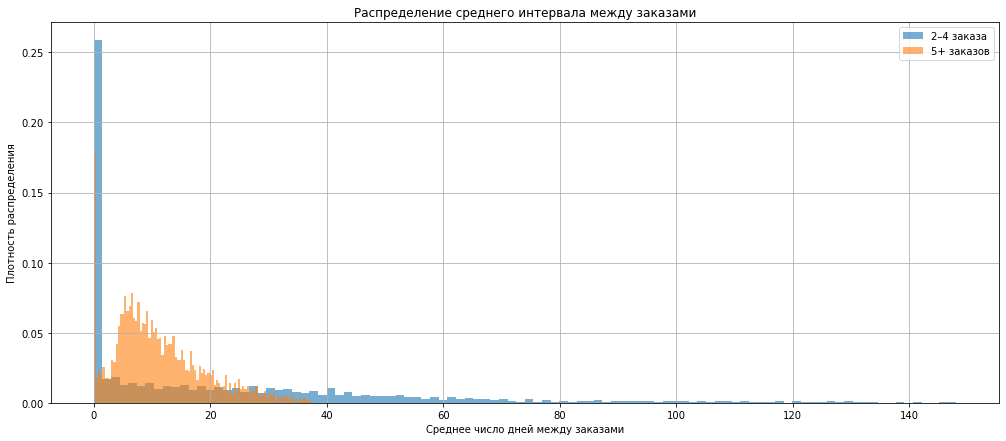

In [101]:
# Визуально сравним распределения
plt.figure(figsize=(17, 7))

plt.hist(
    returned_users.query("orders_group == '2–4 заказа'")['avg_days_between'],
    bins=100,
    alpha=0.6,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    returned_users.query("orders_group == '5+ заказов'")['avg_days_between'],
    bins=100,
    alpha=0.6,
    density=True,
    label='5+ заказов'
)

plt.title('Распределение среднего интервала между заказами')
plt.xlabel('Среднее число дней между заказами')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid()
plt.show()


In [102]:
bins = [0, 7, 14, 30, 60, 120, float('inf')]
labels = ['< 7 дн', '7–14 дн', '14–30 дн', '30–60 дн', '60–120 дн', '120+ дн']

returned_users['interval_segment'] = pd.cut(
    returned_users['avg_days_between'],
    bins=bins,
    labels=labels
)

In [103]:
interval_retention = (
    returned_users
    .groupby('interval_segment')
    .agg(
        users_cnt=('user_id', 'nunique'),
        share_5_plus=('orders_count', lambda x: (x >= 5).mean())
    )
    .reset_index()
)

interval_retention

,interval_segment,users_cnt,share_5_plus
0,< 7 дн,2500,0.623600
1,7–14 дн,2443,0.754400
2,14–30 дн,2536,0.547319
3,30–60 дн,1441,0.088827
4,60–120 дн,588,0.000000
5,120+ дн,93,0.000000


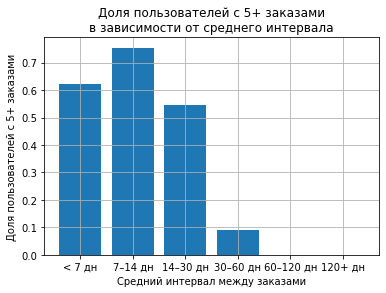

In [104]:
plt.figure()
plt.bar(
    interval_retention['interval_segment'],
    interval_retention['share_5_plus']
)
plt.title('Доля пользователей с 5+ заказами\nв зависимости от среднего интервала')
plt.xlabel('Средний интервал между заказами')
plt.ylabel('Доля пользователей с 5+ заказами')
plt.grid()
plt.show()


In [105]:
interval_retention = (
    returned_users
    .groupby('interval_segment')
    .agg(
        users_cnt=('user_id', 'nunique'),
        share_2_4=('orders_count', lambda x: (x <= 4 ).mean())
    )
    .reset_index()
)

interval_retention

,interval_segment,users_cnt,share_2_4
0,< 7 дн,2500,0.376400
1,7–14 дн,2443,0.245600
2,14–30 дн,2536,0.452681
3,30–60 дн,1441,0.911173
4,60–120 дн,588,1.000000
5,120+ дн,93,1.000000


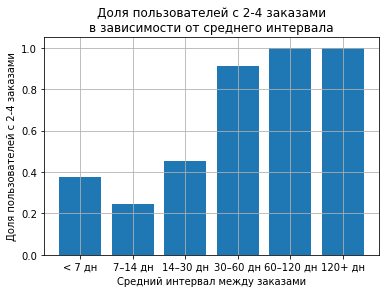

In [106]:
plt.figure()
plt.bar(
    interval_retention['interval_segment'],
    interval_retention['share_2_4']
)
plt.title('Доля пользователей с 2-4 заказами\nв зависимости от среднего интервала')
plt.xlabel('Средний интервал между заказами')
plt.ylabel('Доля пользователей с 2-4 заказами')
plt.grid()
plt.show()


Среди пользователей, совершивших от 2 до 4 самая большая доля возвратов характерна для больших интервалов между покупками - от 60 дней и выше. Для пользователей с покупками больше 5 доля возвратов наибольшая в промежутке от 7 до 14 дней. 

---
<a id="section4.4"></a>
#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---
<a id="section4.4.1"></a>
**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [107]:
# Выбираем признаки
phik_df = user_profile_filtered[[
    'orders_count',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between',
    'first_device_type',
    'first_region_name',
    'first_service_name',
    'first_event_type'
]]

In [108]:
# Указываем интервальные признаки
interval_cols = [
    'orders_count',
    'avg_revenue_rub',
    'avg_tickets',
    'avg_days_between'
]

In [109]:
# Корреляция phi_k для всей выборки
phik_corr = phik_df.phik_matrix(interval_cols=interval_cols)
phik_corr

,orders_count,avg_revenue_rub,avg_tickets,avg_days_between,first_device_type,first_region_name,first_service_name,first_event_type
orders_count,1.000000,0.265381,0.296606,0.487383,0.043218,0.000000,0.041105,0.035094
avg_revenue_rub,0.265381,1.000000,0.453453,0.104249,0.079619,0.367338,0.383699,0.330854
avg_tickets,0.296606,0.453453,1.000000,0.095818,0.057856,0.169730,0.066296,0.100417
avg_days_between,0.487383,0.104249,0.095818,1.000000,0.021819,0.094584,0.057191,0.051056
first_device_type,0.043218,0.079619,0.057856,0.021819,1.000000,0.113026,0.083037,0.062094
first_region_name,0.000000,0.367338,0.169730,0.094584,0.113026,1.000000,0.697671,0.509934
first_service_name,0.041105,0.383699,0.066296,0.057191,0.083037,0.697671,1.000000,0.586834
first_event_type,0.035094,0.330854,0.100417,0.051056,0.062094,0.509934,0.586834,1.000000


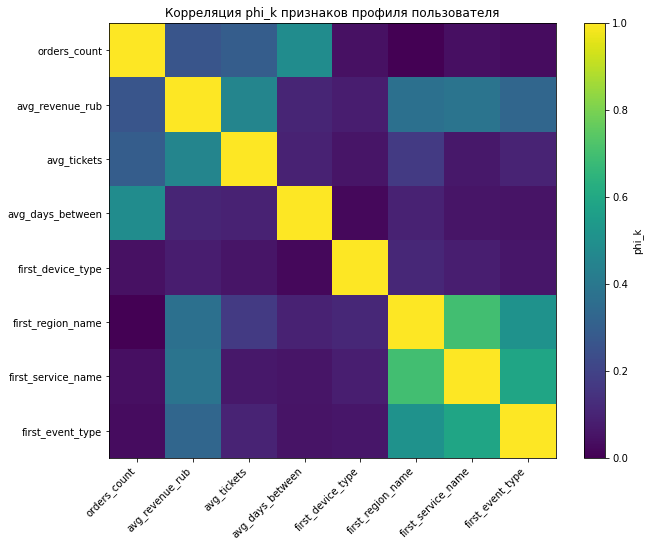

In [110]:
# Построим тепловую карту
plt.figure(figsize=(10, 8))
plt.imshow(phik_corr, aspect='auto')
plt.colorbar(label='phi_k')
plt.xticks(range(len(phik_corr.columns)), phik_corr.columns, rotation=45, ha='right')
plt.yticks(range(len(phik_corr.index)), phik_corr.index)
plt.title('Корреляция phi_k признаков профиля пользователя')
plt.show()

Видим низкие значения `phi_k` для `orders_count`, корреляция близка к нулю. Проверим распределение `orders_count`.

In [111]:
user_profile_filtered['orders_count'].value_counts(normalize=True).head(10)

1     0.403277
2     0.172404
3     0.105207
4     0.067488
5     0.046834
6     0.033744
7     0.025841
8     0.022011
9     0.018375
10    0.013866
Name: orders_count, dtype: float64

Причиной низкой корреляции может быть то, что большинство пользователей имеют 1 заказ и распределение сильно скошено вправо, что размывает корреляцию. Поэтому сделаем сегментацию пользователей по колличеству заказов. 

In [112]:
def orders_segment(x):
    if x == 1:
        return '1 заказ'
    elif x < 5:
        return '2–4 заказа'
    else:
        return '5+ заказов'

user_profile_filtered['orders_segment'] = (
    user_profile_filtered['orders_count']
    .apply(orders_segment)
)

Посчитаем корреляцию для каждого сегмента.

In [113]:
segment_corrs = {}

for segment in user_profile_filtered['orders_segment'].unique():
    segment_df = user_profile_filtered.query('orders_segment == @segment')
    
    corr = segment_df[[
        'orders_count',
        'avg_revenue_rub',
        'avg_tickets',
        'avg_days_between',
        'first_device_type',
        'first_region_name',
        'first_service_name',
        'first_event_type'
    ]].phik_matrix(interval_cols=interval_cols)
    
    segment_corrs[segment] = corr


C:\ProgramData\Anaconda3\lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable orders_count for analysis 1. Dropping this column
  warnings.warn(


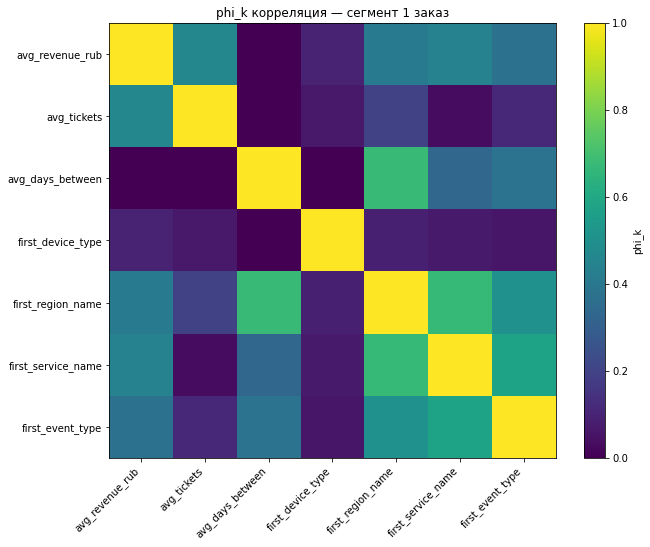

In [114]:
plt.figure(figsize=(10, 8))
plt.imshow(segment_corrs['1 заказ'], aspect='auto')
plt.colorbar(label='phi_k')
plt.xticks(
    range(len(segment_corrs['1 заказ'].columns)),
    segment_corrs['1 заказ'].columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    range(len(segment_corrs['1 заказ'].index)),
    segment_corrs['1 заказ'].index
)
plt.title('phi_k корреляция — сегмент 1 заказ')
plt.show()


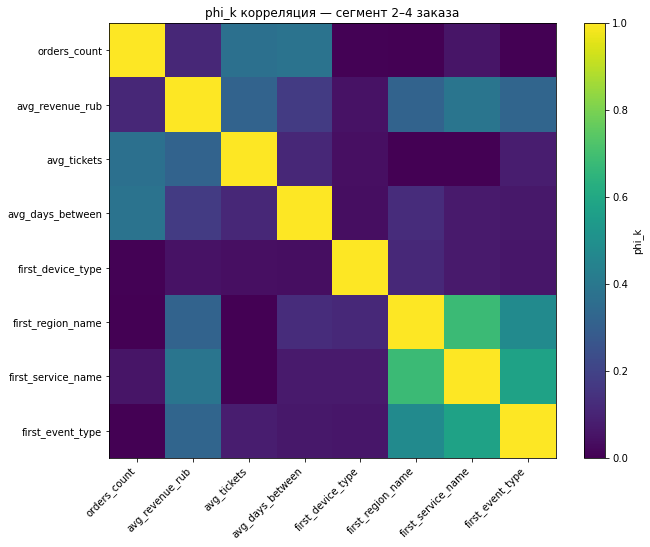

In [115]:
plt.figure(figsize=(10, 8))
plt.imshow(segment_corrs['2–4 заказа'], aspect='auto')
plt.colorbar(label='phi_k')
plt.xticks(
    range(len(segment_corrs['2–4 заказа'].columns)),
    segment_corrs['2–4 заказа'].columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    range(len(segment_corrs['2–4 заказа'].index)),
    segment_corrs['2–4 заказа'].index
)
plt.title('phi_k корреляция — сегмент 2–4 заказа')
plt.show()


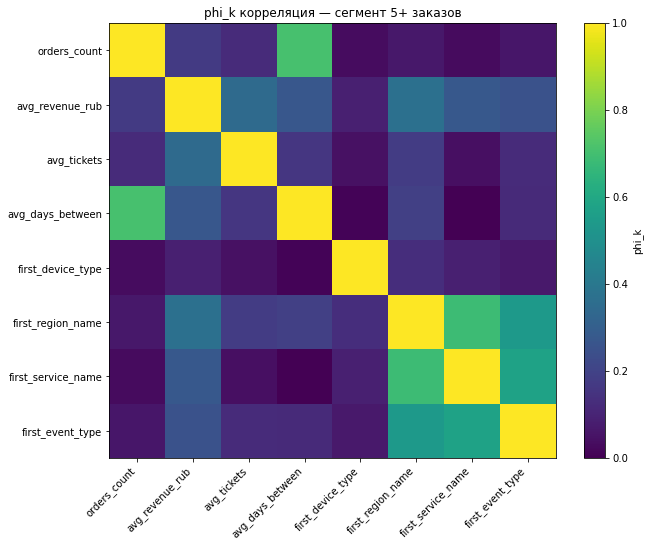

In [116]:
plt.figure(figsize=(10, 8))
plt.imshow(segment_corrs['5+ заказов'], aspect='auto')
plt.colorbar(label='phi_k')
plt.xticks(
    range(len(segment_corrs['5+ заказов'].columns)),
    segment_corrs['5+ заказов'].columns,
    rotation=45,
    ha='right'
)
plt.yticks(
    range(len(segment_corrs['5+ заказов'].index)),
    segment_corrs['5+ заказов'].index
)
plt.title('phi_k корреляция — сегмент 5+ заказов')
plt.show()


Корреляционный анализ показал, что наибольшую связь с количеством заказов имеет контекстный признак - билетный агрегатор. При сегментации связь поведенческих признаков становится более выраженной, что указывает на ключевую роль частоты в формировании лояльной аудитории.

<a id="section5"></a>
### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Первоначально полученная выгрузка данных содержала 290611 строк и 15 столбцов, в которых представлена информация о пользователях и сделанных ими заказах. После первичного анализа было обнаружено, что данные соответсвуют описанию, а типы соответствуют представленным данным. Пропуски в данных соответствовали ожиданию и содержались только в столбце с количеством дней от предыдущей покупки `days_since_prev`.  
В рамках предобработки данных были переведены данные по выручке, приведённые в тенге, в рубли. Значения указаны в новом столбце `revenue_rub`. Сокращена размерность для столбца `tickets_count`. Нормализованы записи с названием типа мероприятия, регионов, городов и билетных операторов. Обнаружено, что в данных есть города с одинаковым названием, но из разных регионов. Из датасета были отфильтрованы отрицательные и нулевые значения выручки, а также выбросы в столбце `revenue_rub` по 99 процентилю. Всего было потеряно 3% данных от общего числа. Отфильтрованные датасет содержит 281879 строк и 16 столбцов.  
После репрезентативного анализа выявлены аномальные значения в данных о количестве заказов. Принято решение отфильтровать их по 95-му перцентилю.  

Всего в выборке 20626 пользователей. Распределение пользователей по числу заказов скошено влево, с правым хвостом. Распределение пользователей по среднему чилсу билетов и количеству дней между покупками показывают похожее поведение.
В целом, доля возвратов во всех сегментах групп пользователей колеблется относительно среднего значения по всей выборке (60 %), но можно отметить следующее:  
- по типу мероприятия - чаще всего возвращаются пользователи, которые первым мероприятием посетили выставку,
- по устройству - не намного, но чаще возвращаются пользователи, сделавшие первый заказ с стационарного устройства,
- по региону - самая большая доля возвратов в Шанырском регионе,
- по билетному оператору - на сервис "Край билетов" возвращались чаще.  

Чаще среднего возвращаются пользователи с 2-3 билетами в заказе. Для понедельника, среды и субботы доля пользователей, совершивших повторный заказ, превышает среднее значение по выборке, что может указывать на потенциальные точки входа. При этом различия между днями не носят резкого характера.  

Корреляционный анализ показал, что наибольшую связь с количеством заказов имеет контекстный признак - билетный агрегатор. При сегментации связь поведенческих признаков становится более выраженной, что указывает на ключевую роль частоты в формировании лояльной аудитории.  

В целом результаты исследования показывают, что удержание пользователей в большей степени зависит от их последующего поведения после первой покупки, а не от контекста входа в сервис. Это подчёркивает важность работы с повторными сценариями, своевременных коммуникаций и стимулов для совершения повторных заказов.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**  

https://github.com/EgorAzovtsev/Final_Project_Tickets_Platform